# Notebook 12 — KymoRoPE: modelo por-pixel a resolución nativa

Implementación de `plan/kymorope-guide.md`. **Este notebook construye y verifica el modelo; no
corre el entrenamiento completo** — §7 está definido y desactivado por bandera, y §7.1 hace una
corrida mínima de verificación (que sí entrena, a una escala que no produce un modelo).

## Qué se verifica acá, y por qué cada cosa

La guía hace tres afirmaciones de diseño que se pueden romper en silencio. Cada sección
las convierte en una aserción:

| §         | afirmación de la guía                                         | se verifica en                       |
| --------- | ------------------------------------------------------------- | ------------------------------------ |
| §2.2      | la RoPE codifica **separación física**, no índices de píxel   | §2, cuatro aserciones                |
| §2.3      | el empaquetado no mezcla muestras                             | §6, aislamiento con control negativo |
| §2.1/§2.4 | nada se redimensiona y la salida vuelve a resolución completa | §3.1, extremos 48×99 y 463×2722      |

Más lo que hace falta para que un entrenamiento no se caiga a la mitad: gradientes por los tres
heads (§4) y el costo real en memoria de MPS con y sin _checkpointing_ (§5).

**Dispositivo**: Apple Silicon / MPS. `PYTORCH_ENABLE_MPS_FALLBACK=1` va **antes** de
`import torch` (mismo patrón que `scripts/entrenar_atencion_v1.py`), todo en float32 — MPS no
soporta float64.


---

## 0. Setup


In [1]:
import gc
import os
import sys
import time
import types
import warnings
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # ANTES de importar torch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import torch

RAIZ = Path("..").resolve()
sys.path.append(str(RAIZ / "src"))
warnings.filterwarnings("ignore", message=".*requires_grad.*")

from axonal_tracking import datos_pixel as dp
from axonal_tracking import kymorope as kr

DISPOSITIVO = kr.dispositivo_preferido()
print("dispositivo:", DISPOSITIVO)
for k, v in kr.resumen_dispositivo().items():
    print(f"  {k:12s} {v}")

dispositivo: cuda
  dispositivo  cuda
  torch        2.12.0+cu130
  gpu          NVIDIA GeForce RTX 3060 Laptop GPU
  vram_gb      6.4
  capacidad    8.6
  asignado_mb  0.0
  reservado_mb 0.0


---

## 1. Targets por-píxel (§3 de la guía)

Los tres targets salen de `positions.csv` a través de **las mismas funciones que exportan las
etiquetas de los otros pipelines** (`mascara_traza` / `ids_que_se_mueven`), espejo L-R incluido.
No hay un segundo rasterizador: duplicarlo es como se reintroduce el bug que la docstring de
`mascara_traza(dilatar=False)` documenta.

La decisión abierta de §3 queda **cerrada acá como opción 1**: los píxeles reclamados por ≥2
partículas se excluyen del término de atracción (`mask_pull`) y de la pérdida de orientación
(`mask_theta`). Promediar dos identidades en un cruce es exactamente el modo de falla que el
head de embedding existe para evitar.


In [2]:
MUESTRA = "sample_00099"  # 5 móviles, 4 de ellas se cruzan
d = RAIZ / "datasets" / "test" / MUESTRA

kymo_crudo = tifffile.imread(d / "kymograph.tif")
positions = pd.read_csv(d / "positions.csv")
tg = dp.construir_targets(positions, kymo_crudo.shape)

clases, cuentas = np.unique(tg.trackness, return_counts=True)
frac = cuentas / cuentas.sum()
print(f"{MUESTRA}: T={kymo_crudo.shape[0]}  L={kymo_crudo.shape[1]}")
print(
    f"  trackness  fondo {frac[0]:.3f} | estatica {frac[1]:.3f} | movil {frac[2]:.3f}"
)
print(f"  instancias moviles: {tg.n_instancias}")
es_traza = tg.trackness > 0
print(
    f"  supervision: theta sobre {tg.mask_theta.sum() / es_traza.sum():.1%} de los px de traza"
)
print(
    f"               pull  sobre {tg.mask_pull.sum() / (tg.trackness == 2).sum():.1%} de los px moviles"
)
print(
    "  -> el resto son px reclamados por >=2 particulas, excluidos a proposito (opcion 1)"
)
print(
    f"  norma de theta: {np.linalg.norm(tg.theta, axis=-1).min():.4f} .. "
    f"{np.linalg.norm(tg.theta, axis=-1).max():.4f}  (debe ser 1)"
)

sample_00099: T=186  L=902
  trackness  fondo 0.836 | estatica 0.132 | movil 0.032
  instancias moviles: 4
  supervision: theta sobre 84.0% de los px de traza
               pull  sobre 75.6% de los px moviles
  -> el resto son px reclamados por >=2 particulas, excluidos a proposito (opcion 1)
  norma de theta: 1.0000 .. 1.0000  (debe ser 1)


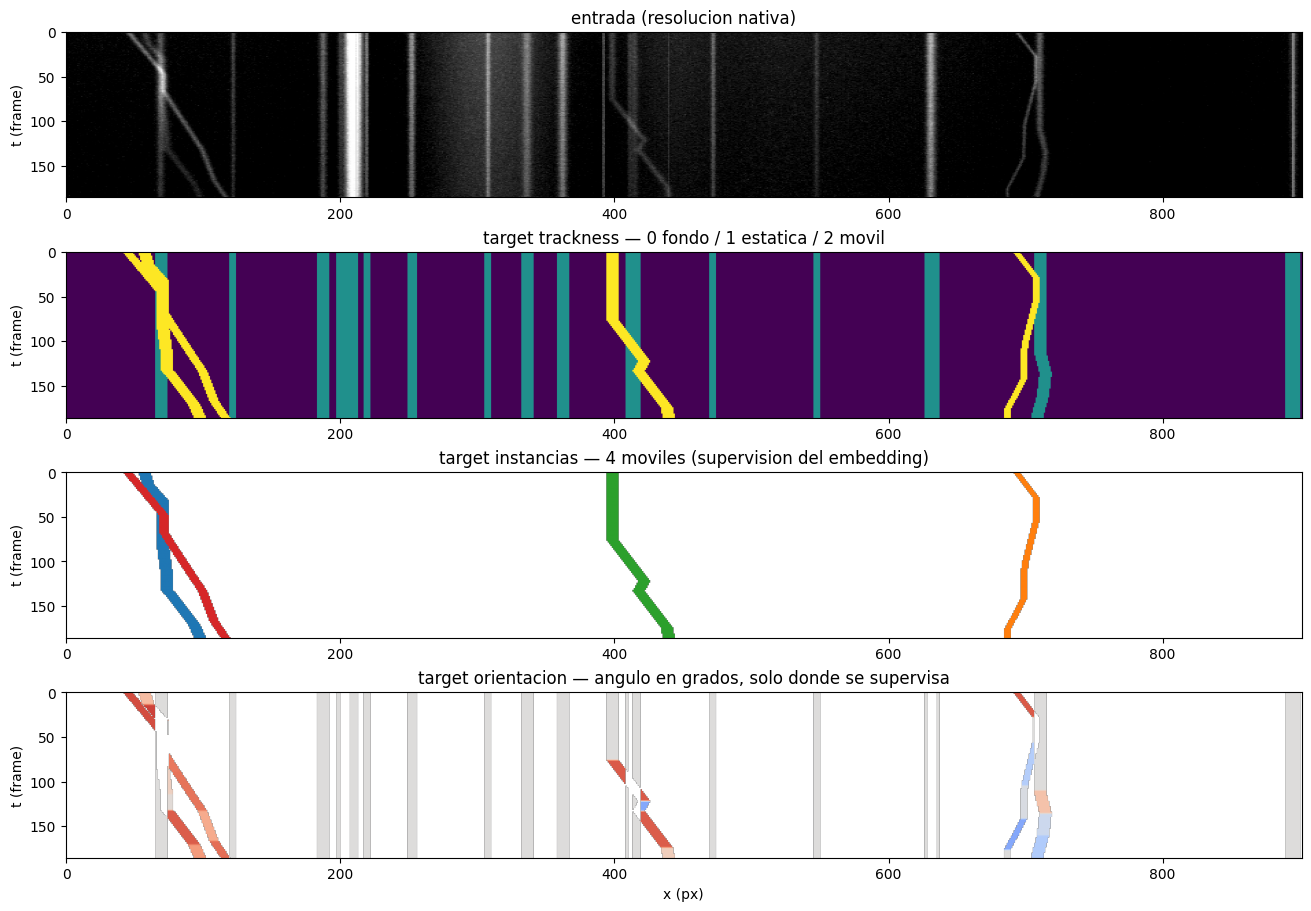

In [3]:
# Los tres targets, como los ve la perdida
fig, axs = plt.subplots(4, 1, figsize=(13, 9), constrained_layout=True)
lo, hi = np.percentile(kymo_crudo, [50, 99.8])
axs[0].imshow(kymo_crudo, cmap="gray", vmin=lo, vmax=hi, aspect="auto")
axs[0].set_title("entrada (resolucion nativa)")
axs[1].imshow(tg.trackness, cmap="viridis", vmin=0, vmax=2, aspect="auto")
axs[1].set_title("target trackness — 0 fondo / 1 estatica / 2 movil")
axs[2].imshow(
    np.where(tg.instancias > 0, tg.instancias, np.nan),
    cmap="tab10",
    vmin=1,
    vmax=10,
    aspect="auto",
)
axs[2].set_title(
    f"target instancias — {tg.n_instancias} moviles (supervision del embedding)"
)
ang = np.degrees(np.arctan2(tg.theta[..., 0], tg.theta[..., 1]))
axs[3].imshow(
    np.where(tg.mask_theta, ang, np.nan),
    cmap="coolwarm",
    vmin=-35,
    vmax=35,
    aspect="auto",
)
axs[3].set_title("target orientacion — angulo en grados, solo donde se supervisa")
for ax in axs:
    ax.set_ylabel("t (frame)")
axs[3].set_xlabel("x (px)")
plt.show()

---

## 2. La RoPE física (§2.2) — cuatro aserciones

La afirmación de la guía es que la codificación depende de la **separación física** entre dos
tokens (Δt en segundos, Δx en µm), no de su separación en índices. Si eso no se cumple, la
invariancia a la tasa de muestreo de §5.3 es decorativa y el resto del argumento se cae.

1. **Relativa**: trasladar ambos tokens no cambia el producto q·k.
2. **Invariancia de fps**: la misma Δt física obtenida desde dos fps distintos da el mismo
   producto. Fila 1 a 3.29 fps ≡ fila 1.5745 a 5.18 fps.
3. **Control negativo**: si las frecuencias ignoraran `dt`, (2) daría 0 por construcción. Se
   comprueba que _no_ dar el mismo Δt sí cambia el producto.
4. **Cableado**: `dt` llega efectivamente al modelo completo, no sólo al módulo.


In [4]:
torch.manual_seed(0)
rope = kr.RoPE2DFisica(64).to(DISPOSITIVO)


def producto(t_seg, x_um, q, k):
    cos, sin = rope(
        torch.tensor(t_seg, device=DISPOSITIVO), torch.tensor(x_um, device=DISPOSITIVO)
    )
    return (
        kr.aplicar_rope(q, cos, sin) @ kr.aplicar_rope(k, cos, sin).transpose(-1, -2)
    ).squeeze()


q = torch.randn(1, 1, 2, 64, device=DISPOSITIVO)
k = torch.randn(1, 1, 2, 64, device=DISPOSITIVO)

# (1) relativa
A = producto([0.0, 1.2], [0.0, 3.5], q, k)
B = producto([7.3, 8.5], [11.0, 14.5], q, k)
e1 = float((A - B).abs().max())

# (2) invariancia de fps: misma separacion FISICA, dos tasas de muestreo del dataset
dt_lento, dt_rapido = 1 / 3.29, 1 / 5.18
fila_equiv = dt_lento / dt_rapido
C = producto([0.0, dt_lento * 1], [0.0, 0.0], q, k)
D = producto([0.0, dt_rapido * fila_equiv], [0.0, 0.0], q, k)
e2 = float((C - D).abs().max())

# (3) control negativo: una fila a 5.18 fps NO es la misma Dt fisica
E = producto([0.0, dt_rapido * 1], [0.0, 0.0], q, k)
e3 = float((C - E).abs().max())

print(f"(1) relativa            max|A-B| = {e1:.2e}   (~0)")
print(
    f"(2) invariancia de fps  max|C-D| = {e2:.2e}   (~0)  fila 1 @3.29fps == fila {fila_equiv:.4f} @5.18fps"
)
print(f"(3) control negativo    max|C-E| = {e3:.2e}   (>> 0)")
assert e1 < 1e-3, "la RoPE no es relativa"
assert e2 < 1e-4, "la RoPE no es invariante a la tasa de muestreo"
assert e3 > 1e-1, "control negativo: dt no esta cambiando nada"
print("\nOK: la codificacion depende de la separacion FISICA, no de indices.")

(1) relativa            max|A-B| = 3.05e-05   (~0)
(2) invariancia de fps  max|C-D| = 0.00e+00   (~0)  fila 1 @3.29fps == fila 1.5745 @5.18fps
(3) control negativo    max|C-E| = 6.62e-01   (>> 0)

OK: la codificacion depende de la separacion FISICA, no de indices.


In [5]:
# (4) dt llega al modelo completo, no solo al modulo
ds_mini = dp.DatasetKymografos(RAIZ / "datasets" / "test", limite=1)
mu = ds_mini[0]
mu_2x = types.SimpleNamespace(**{**mu.__dict__, "dt_segundos": mu.dt_segundos * 2})

modelo_test = kr.KymoRoPE(n_capas=2).to(DISPOSITIVO).eval()
with torch.no_grad():
    o1 = modelo_test([mu])[0].trackness
    o2 = modelo_test([mu_2x])[0].trackness
e4 = float((o1 - o2).abs().max())
print(f"(4) cableado  max|salida(dt) - salida(2*dt)| = {e4:.4f}   (> 0)")
assert e4 > 1e-4, "dt no llega al forward: la RoPE fisica no esta conectada"
print("OK: dt esta cableado de punta a punta.")
del modelo_test, o1, o2
gc.collect()
kr.vaciar_cache()

(4) cableado  max|salida(dt) - salida(2*dt)| = 0.0132   (> 0)
OK: dt esta cableado de punta a punta.


---

## 3. El modelo (§2)


In [6]:
modelo = kr.KymoRoPE().to(DISPOSITIVO)
por_bloque = {}
for nombre, p in modelo.named_parameters():
    por_bloque[nombre.split(".")[0]] = (
        por_bloque.get(nombre.split(".")[0], 0) + p.numel()
    )
total = sum(por_bloque.values())
for nombre, n in sorted(por_bloque.items(), key=lambda t: -t[1]):
    print(f"  {nombre:18s} {n:>11,d}  ({100 * n / total:4.1f}%)")
print(f"  {'TOTAL':18s} {total:>11,d}  ({total / 1e6:.2f} M)")
print("\n  RoPE: 0 parametros (frecuencias fijas), sin PE aprendida, sin CLS")
print(
    f"  lambda_t = {kr.LAMBDA_MIN_T_S}..{kr.LAMBDA_MAX_T_S} s | "
    f"lambda_x = {kr.LAMBDA_MIN_X_UM}..{kr.LAMBDA_MAX_X_UM} um"
)

  bloques             21,293,568  (82.8%)
  stem                 3,814,528  (14.8%)
  decoder                594,528  ( 2.3%)
  ln_final                   768  ( 0.0%)
  head_embedding             520  ( 0.0%)
  head_trackness             195  ( 0.0%)
  head_orientacion           130  ( 0.0%)
  TOTAL               25,704,237  (25.70 M)

  RoPE: 0 parametros (frecuencias fijas), sin PE aprendida, sin CLS
  lambda_t = 0.4..320.0 s | lambda_x = 0.2..640.0 um


### 3.1 Formas extremas — nada se redimensiona

El dataset va de 48×99 a 463×2722 (~300× de rango en cantidad de tokens). El punto del diseño
es no redimensionar nunca, así que las dos puntas tienen que pasar tal cual.


In [7]:
def muestra_falsa(T, L, dt=0.304, dx=0.107, device=None):
    """(T, L) aleatorio con la interfaz que espera el modelo."""
    dev = device or DISPOSITIVO
    o = types.SimpleNamespace(nombre=f"{T}x{L}", dt_segundos=dt, dx_um=dx)
    o.kymo = torch.rand(1, T, L, device=dev)
    return o


modelo.eval()
print(f"{'forma':>12} {'tokens':>7} {'fwd s':>7} {'pico MB':>9}   salida")
for T, L in [(48, 99), (52, 1613), (218, 1316), (463, 2722)]:
    gc.collect()
    kr.vaciar_cache()
    base = kr.memoria_reservada()
    x = muestra_falsa(T, L)
    kr.sincronizar()
    t0 = time.time()
    with torch.no_grad():
        s = modelo([x])[0]
    kr.sincronizar()
    print(
        f"{T:5d}x{L:<6d} {dp.tokens_de_forma((T, L)):7d} {time.time() - t0:7.2f} "
        f"{(kr.memoria_reservada() - base) / 1e6:9.0f}   {tuple(s.trackness.shape)}"
    )
    del x, s
gc.collect()
kr.vaciar_cache()

       forma  tokens   fwd s   pico MB   salida
   48x99          21    0.05         2   (3, 48, 99)
   52x1613       404    0.02        40   (3, 52, 1613)
  218x1316      1162    0.03       208   (3, 218, 1316)
  463x2722      4959    0.10       916   (3, 463, 2722)


---

## 4. Pérdidas y gradientes (§2.5)

`L = λ₁·(CE+Dice) + λ₂·discriminativa + λ₃·coseno`. El desglose se mira por separado a
propósito: si el embedding colapsa mientras el trackness baja, el total no lo muestra.

El chequeo que importa: **ningún parámetro sin gradiente**. Un head desconectado entrena sin
error y da basura.


In [8]:
def a_dispositivo(m, device=None):
    """Mueve los tensores de una MuestraPixel al dispositivo."""
    dev = device or DISPOSITIVO
    campos = ["kymo", "trackness", "instancias", "theta", "mask_pull", "mask_theta"]
    return type(m)(**{**m.__dict__, **{c: getattr(m, c).to(dev) for c in campos}})


ds = dp.DatasetKymografos(RAIZ / "datasets" / "test", limite=4)
muestra = a_dispositivo(ds[0])

modelo.train()
salida = modelo([muestra])[0]
perdidas = kr.perdida_total(salida, muestra)
perdidas["total"].backward()

print("perdidas (modelo sin entrenar):")
for nombre, v in perdidas.items():
    print(f"  {nombre:12s} {float(v.detach()):.4f}")
sin_grad = [n for n, p in modelo.named_parameters() if p.grad is None]
no_finito = [
    n
    for n, p in modelo.named_parameters()
    if p.grad is not None and not torch.isfinite(p.grad).all()
]
print(f"\nparametros sin gradiente : {len(sin_grad)}   (debe ser 0)")
print(f"gradientes no finitos    : {len(no_finito)}   (debe ser 0)")
assert not sin_grad and not no_finito
print("\n|grad| por head:")
for n, p in modelo.named_parameters():
    if n.startswith("head_"):
        print(f"  {n:34s} {float(p.grad.norm()):.3e}")
modelo.zero_grad(set_to_none=True)
del salida, perdidas
gc.collect()
kr.vaciar_cache()

perdidas (modelo sin entrenar):
  total        2.2663
  trackness    2.0594
  embedding    0.1517
  orientacion  0.1104

parametros sin gradiente : 0   (debe ser 0)
gradientes no finitos    : 0   (debe ser 0)

|grad| por head:
  head_trackness.weight              1.895e+00
  head_trackness.bias                6.238e-01
  head_embedding.weight              3.568e+00
  head_embedding.bias                8.625e-04
  head_orientacion.weight            1.261e+00
  head_orientacion.bias              4.317e-01


---

## 5. MPS: el _checkpointing_ no es opcional en la cola larga

Medición real de un paso completo (forward + backward + `AdamW.step`) con el modelo de 12 capas.
`usar_checkpoint=True` recalcula las activaciones de cada bloque en el backward en vez de
guardarlas.


In [9]:
def muestra_falsa_completa(T, L):
    o = muestra_falsa(T, L)
    o.trackness = torch.randint(0, 3, (T, L), device=DISPOSITIVO)
    o.instancias = torch.randint(0, 6, (T, L), device=DISPOSITIVO)
    o.theta = torch.nn.functional.normalize(
        torch.rand(2, T, L, device=DISPOSITIVO), dim=0
    )
    o.mask_pull = o.instancias > 0
    o.mask_theta = o.trackness > 0
    return o


# Se mide `current_allocated_memory` (suma de tensores VIVOS) justo despues del
# forward: eso es exactamente la memoria de activaciones que el checkpointing no
# guarda. El delta de `driver_allocated_memory` NO sirve para comparar dos configs
# en el mismo kernel -- el pool del asignador no se devuelve entre mediciones y la
# segunda config parece gratis.
print(f"{'forma':>12} {'checkpoint':>11} {'paso s':>7} {'activaciones MB':>16}")
filas_mem = []
for T, L in [(218, 1316), (463, 2722)]:
    for ck in (False, True):
        gc.collect()
        kr.vaciar_cache()
        m = kr.KymoRoPE(usar_checkpoint=ck).to(DISPOSITIVO).train()
        opt = torch.optim.AdamW(m.parameters(), lr=1e-4)
        x = muestra_falsa_completa(T, L)
        kr.sincronizar()
        base = kr.memoria_asignada()
        t0 = time.time()
        perdida = kr.perdida_total(m([x])[0], x)["total"]
        kr.sincronizar()
        activaciones = (kr.memoria_asignada() - base) / 1e6
        perdida.backward()
        opt.step()
        opt.zero_grad(set_to_none=True)
        kr.sincronizar()
        dt_s = time.time() - t0
        filas_mem.append((f"{T}x{L}", ck, dt_s, activaciones))
        print(f"{T:5d}x{L:<6d} {ck!s:>11} {dt_s:7.2f} {activaciones:16.0f}")
        del m, opt, x, perdida
gc.collect()
kr.vaciar_cache()

       forma  checkpoint  paso s  activaciones MB
  218x1316         False    0.18              454
  218x1316          True    0.11              360
  463x2722         False    0.41             1959
  463x2722          True    0.44             1554


**De dónde sale la memoria, medido**: no del decoder — de la **atención**.
`scaled_dot_product_attention` en MPS **materializa la matriz completa**: no hay kernel
fusionado, con máscara o sin ella. Medido a `B=3, H=6, N=2726`: **0.57 GB por capa**, × 12
capas ≈ 6.8 GB. Escala con `B · N_max²`, así que el lote peor del dataset manda.

Sobre ese peor lote real, paso completo:

| `max_tokens` | checkpoint | activaciones | s/paso | min/época |
| ------------ | ---------- | -----------: | -----: | --------: |
| 8192         | off        | **12.60 GB** |   2.07 |       5.1 |
| 8192         | **on**     |  **3.78 GB** |   2.38 |   **5.9** |
| 4096         | off        |      9.64 GB |   1.54 |       7.7 |
| 4096         | on         |      2.36 GB |   1.50 |       7.5 |

**3.3× menos memoria por 15 % de tiempo**, así que el checkpointing queda activado. Bajar
`max_tokens` acota `N_max` pero multiplica los pasos y sale más caro por época.

### El parche del stem — medido, y con una trampa

La atención va como `B · N²` y `N = píxeles / parche²`, así que subir el stem de stride 16 a 32
divide `N` por 4. **Pero el presupuesto de lote está en tokens y el stem/decoder cuestan por
píxel**: con el mismo `max_tokens`, el parche 32 mete ~2.7× más píxeles por lote y la memoria
**sube**. Medido sobre el peor lote real:

| parche | `max_tokens` |   B | N_max |  Mpx | activaciones |   s/paso | min/época |
| ------ | -----------: | --: | ----: | ---: | -----------: | -------: | --------: |
| 16     |         8192 |   3 |  2728 | 2.03 |      3.78 GB |     2.59 |       6.4 |
| 32     |         8192 |   8 |  1200 |    — | **10.31 GB** |     3.19 |       5.3 |
| **32** |     **2048** |   2 |  1008 | 1.98 |  **2.45 GB** | **0.83** |   **2.1** |

Con el presupuesto de **píxeles** igualado (2048 tokens a parche 32 ≈ 8192 a parche 16), el
parche 32 gana en las dos cosas: **35 % menos memoria y 3× más rápido**. Por eso
`kymorope.PARCHE = 32` y `entrenamiento.MAX_TOKENS_LOTE = 2048` se mueven juntos — si tocás uno
sin el otro, la memoria explota.

**Lo que esto cuesta y no está medido**: cada token cubre ahora 32×32 px en vez de 16×16, o sea
contexto más grueso en el encoder. La resolución de **salida** no cambia (el decoder sigue
recibiendo skips en s2/s4 y los heads suben a full-res), así que el riesgo es de granularidad de
contexto, no de precisión espacial. Si hace daño, lo dice el gate de §7 de la guía y no este
notebook. `KymoRoPE(parche=16)` vuelve al anterior.

**Advertencia operativa**: si interrumpís una celda en pleno `backward()` con checkpointing
activo, el hook de tensores guardados queda instalado en el kernel y **todo forward posterior
aborta** con `CheckpointError` (el contador de "tensores guardados en el forward" crece run a
run mientras el de recómputo queda fijo en el tamaño de un bloque). Única salida:
**Restart Kernel**.

Medición aparte, en procesos frescos (un `driver_allocated_memory` por config, sin pool
contaminado): el paso completo sobre 463×2722 pide **~17 GB sin checkpointing y ~5.6 GB con**.
Esa es la diferencia entre entrenar y no entrenar en una Mac de 16 GB.


---

## 6. Pipeline de datos (§2.3) — empaquetado sin padding

El stem corre por muestra (las convoluciones no se batchean con formas distintas) y los tokens
se apilan **paddeados** a `(B, N_max, d)` con una máscara de clave.

**Por qué padding y no una secuencia concatenada con máscara bloque-diagonal** (que es como
estaba): las dos son matemáticamente idénticas — las muestras nunca se atienden entre sí — pero
`scaled_dot_product_attention` calcula la matriz completa aunque la máscara después tape casi
todo. Concatenar B muestras de N tokens cuesta `(B·N)²` en vez de `B·N²`, o sea **B veces de
más**. Medido con 7 muestras de 1162 tokens: 1.10 s contra 0.23 s por pasada del encoder
(**4.8×**). Es el cambio que bajó la época de ~17 min a ~5.

El padding entra sólo como **clave** enmascarada; las filas de query padeadas se calculan igual
y se descartan al cortar. Así ninguna fila de la máscara queda toda en `False`, que es lo que
daría `NaN` en SDPA.

El bucketing agrupa por **conteo de tokens**, no por número de muestras. Con el lote paddeado el
costo es `B·N_max²`, así que además conviene que las muestras de un lote tengan tamaños
parecidos — por eso se ordena por costo antes de cortar.


In [10]:
# las 800 originales: el train ahora tiene 33 000, y leer el fps de todas tarda ~1 min.
# Con estas 800 las cifras de abajo son las mismas que documenta el texto.
ds_train = dp.DatasetKymografos(RAIZ / "datasets" / "train", subconjunto=800)
formas = ds_train.formas()
lotes = dp.agrupar_por_tokens(formas, max_tokens=8192, max_muestras=8)
costos = [sum(dp.tokens_de_forma(formas[i]) for i in lote) for lote in lotes]
tam = [len(lote) for lote in lotes]
print(f"{len(formas)} muestras -> {len(lotes)} lotes")
print(
    f"  tokens por lote : min {min(costos)}  mediana {int(np.median(costos))}  max {max(costos)}  (tope 8192)"
)
print(
    f"  muestras por lote: min {min(tam)}  mediana {int(np.median(tam))}  max {max(tam)}"
)
print(f"  fps presentes   : {sorted(set(ds_train.fps()))}")

800 muestras -> 149 lotes
  tokens por lote : min 875  mediana 6977  max 8181  (tope 8192)
  muestras por lote: min 1  mediana 5  max 8
  fps presentes   : [3.29, 3.5, 4.0, 4.83, 5.18]


In [11]:
# Aislamiento del lote paddeado, con control negativo: sin mascara de clave, el
# padding de las otras muestras entra a la atencion y contamina el resultado.
#
# `fp32_estricto()`: en CUDA (Ampere+) las convoluciones float32 corren en TF32 por
# defecto (~5e-4 relativo) y redondean a esa resolucion la diferencia de ~1e-6 que
# traen los dos caminos del encoder -- medido en una RTX 3060: 6.9e-04 con TF32,
# 1.3e-06 sin. Una asercion de equivalencia se mide en fp32 real. En MPS/CPU no
# cambia nada.
modelo.eval()
a, b = ds[0], ds[1]
original = kr.AtencionRoPE.forward


def _sin_mascara(self, x, cos, sin, mascara):
    return original(self, x, cos, sin, None)


with torch.no_grad(), kr.fp32_estricto():
    sola = modelo([a])[0].trackness
    en_lote = modelo([a, b])[0].trackness
    try:
        kr.AtencionRoPE.forward = _sin_mascara
        fugado = modelo([a, b])[0].trackness
    finally:
        kr.AtencionRoPE.forward = original

aislado = float((sola - en_lote).abs().max())
fuga = float((sola - fugado).abs().max())
print(
    f"formas del lote: {[tuple(x.kymo.shape[-2:]) for x in (a, b)]}  -> hay padding real"
)
print(f"con mascara de clave  : max|sola - en lote| = {aislado:.2e}   (~0)")
print(f"sin mascara (control) : max|sola - en lote| = {fuga:.2e}   (>> 0)")
assert aislado < 1e-4 and fuga > 1e-4
print("\nOK: el padding no contamina a las otras muestras del lote.")
del sola, en_lote, fugado
gc.collect()
kr.vaciar_cache()

formas del lote: [(170, 979), (162, 1598)]  -> hay padding real
con mascara de clave  : max|sola - en lote| = 1.55e-06   (~0)
sin mascara (control) : max|sola - en lote| = 3.21e-01   (>> 0)

OK: el padding no contamina a las otras muestras del lote.


---

## 7. Entrenamiento — `Trainer.train_model_v2`, no un bucle propio

El bucle escrito a mano se reemplazó por `notebooks/trainer.py::Trainer.train_model_v2` (AMP,
acumulación de gradiente, clipping, checkpointing, scheduler en el borde de acumulación, tqdm).
`src/axonal_tracking/entrenamiento.py` lo adapta sobreescribiendo **sólo** `compute_loss` /
`compute_eval_loss`, que es el único punto donde KymoRoPE no encaja con la clase base:

| `Trainer` asume          | KymoRoPE entrega                                                   |
| ------------------------ | ------------------------------------------------------------------ |
| `(input, target)` densos | `LoteEmpaquetado` — muestras de tamaño distinto, sin apilar (§2.3) |
| `model(x) -> tensor`     | `model(lista) -> lista de SalidaKymoRoPE`, 3 heads                 |
| `loss_fn(out, target)`   | `perdida_total(salida, muestra) -> dict` con desglose              |

### Dos correcciones en `trainer.py`

Afectan a cualquiera que use la clase, no sólo a este modelo:

1. **Escalado de gradiente con bf16 (bug real).** `train_model_v2` hacía
   `scaler.scale(loss).backward()` cuando `dtype` era `float16` **o** `bfloat16`, pero después
   sólo llamaba `scaler.step()` en el caso `float16`. Con bf16 los gradientes llegaban al
   optimizador multiplicados por el factor de escala (65536 por defecto) y sin desescalar. El
   `clip_grad_norm_(…, 1.0)` lo tapaba — renormalizaba todo a norma 1.0 en cada paso, con lo
   que la acumulación dejaba de significar nada. Ahora el scaler se habilita **sólo** en fp16
   (bf16 tiene el mismo rango de exponente que fp32 y no lo necesita) y el camino escalado usa
   siempre `scaler.step()`.
2. **`torch.cuda.empty_cache()` al final.** Sin CUDA es un no-op silencioso: en MPS no liberaba
   nada. Ahora vacía la caché del backend que corresponda.

También `save_checkpoint` guardaba `scaler_state_dict` sólo si `hasattr(self, "scaler")`, y
`train_model_v2` creaba el scaler como variable **local** — o sea, nunca se guardaba.

### Una que se dejó como estaba, señalada

`clip_grad_norm_` corre en **cada micro-batch**, no una vez antes del `optimizer.step()`. Eso
renormaliza progresivamente las acumulaciones parciales, que no es lo habitual. Cambiarlo altera
la dinámica de entrenamiento de cualquiera que ya use la clase, así que queda como está con un
comentario. Vale la pena decidirlo explícitamente.

### Parada temprana — deliberadamente sin cablear

`eval_model()` devuelve **pérdida de píxel**. §7 de la guía y `plan/decnet-finetune-guide.md`
piden parar por `frac_id_switch` a nivel trayectoria, y las dos métricas no se mueven juntas.
`entrenamiento.metrica_parada_temprana()` levanta `NotImplementedError` hasta que exista la
decodificación de §2.6: un `EarlyStopping` mal cableado es peor que ninguno, porque parece que
funciona.

### Tres modos de `entrenar()`

| modo      | llamada                                                                                      | qué pasa                                                                                 |
| --------- | -------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| de cero   | `entrenar("nombre", epocas=40)`                                                              | pesos aleatorios; optimizador y OneCycle nuevos                                          |
| fine-tune | `entrenar("nombre", pesos_iniciales=MODELO_5K, lr=1e-4, muestras_por_epoca=5000, epocas=20)` | carga **solo los pesos**; optimizador y OneCycle nuevos, dimensionados para esta corrida |
| reanudar  | `entrenar("nombre", reanudar=True, <los mismos argumentos>)`                                 | sigue desde la última época completa; con otros argumentos se niega                      |

Cada corrida guarda en su propia carpeta, `results/kymorope/checkpoints/<nombre>/`
(`checkpoint_final.pt` + `historia.csv`, actualizados al final de cada época), así un fine-tune
no pisa el modelo del que parte.

**Datos.** `datasets/train` tiene ahora 33 000 muestras (15 perfiles de generador); las 800
originales siguen adentro, y `subconjunto_train=N` toma N representativas y anidadas que las
incluyen. Los targets marcan móvil a partir de **8 px**, el mismo umbral del harness: hasta el
2026-09-27 eran 4 px por un desliz, y `MODELO_800` se entrenó así — el fine-tune lo corrige.

### Curva de escala de datos

Cada etapa parte del modelo de la anterior, con conjuntos anidados (800 ⊂ 5 000 ⊂ 33 000), así
cada paso mide sólo lo que agregan los datos nuevos:

| etapa | corrida                                      | parte de         | datos                       | épocas                | estado                |
| ----- | -------------------------------------------- | ---------------- | --------------------------- | --------------------- | --------------------- |
| base  | `kymorope_40ep_2026-09-24.pt` (`MODELO_800`) | pesos aleatorios | las 800 originales          | 40                    | hecho                 |
| 1     | `finetune_5k` (`MODELO_5K`)                  | base             | 5 000 representativas       | 8                     | hecho                 |
| 2     | `finetune_33k`                               | etapa 1          | las 33 000, 5 000 por época | 20 (~3 pasadas, ~3 h) | **la celda de abajo** |

`muestras_por_epoca=5000` arma épocas cortas que recorren el dataset sin repetir dentro de cada
pasada: validación cada ~9 min y, si se corta, `reanudar=True` pierde a lo sumo una de esas épocas.


In [12]:
EJECUTAR_ENTRENAMIENTO = (
    True  # True lanza la etapa 2 de abajo (fine-tune sobre las 33 000, ~3 h)
)

from axonal_tracking import entrenamiento as ent

CHECKPOINTS = RAIZ / "results" / "kymorope" / "checkpoints"
MODELO_800 = (
    CHECKPOINTS / "kymorope_40ep_2026-09-24.pt"
)  # 40 epocas sobre las 800 originales
MODELO_5K = (
    CHECKPOINTS / "finetune_5k" / "checkpoint_final.pt"
)  # etapa 1: MODELO_800 afinado 8 epocas sobre 5000


def entrenar(
    corrida,
    epocas=40,
    *,
    pesos_iniciales=None,
    reanudar=False,
    raiz_datasets=RAIZ / "datasets",
    fps_excluido=None,
    use_amp=True,
    dtype=torch.bfloat16,
    usar_checkpoint=None,  # None = decide por VRAM (MPS siempre; CUDA si <12 GB)
    **kw,
):
    """Entrenamiento via `Trainer.train_model_v2`. Devuelve (entrenador, historia).

    **Una funcion, tres modos** (tabla en el markdown de arriba):

    - de cero: `entrenar("nombre", epocas=...)`;
    - fine-tune: `entrenar("nombre", pesos_iniciales=ruta.pt, lr=1e-4, ...)`. Carga SOLO
      los pesos del modelo; optimizador y scheduler arrancan nuevos, dimensionados para
      esta corrida;
    - reanudar: `entrenar("nombre", reanudar=True, <los MISMOS argumentos>)`. Sigue desde
      la ultima epoca completa. Con otros argumentos se niega: el scheduler cargado
      quedaria desfasado (`TrainerKymoRoPE.cargar_checkpoint`).

    `corrida` es el nombre de su carpeta de checkpoints (`results/kymorope/checkpoints/
    <corrida>/`). Cada corrida tiene la suya: un fine-tune no pisa el modelo del que
    parte, y arrancar una corrida que ya existe sin `reanudar=True` se rechaza. La
    historia va a `historia.csv` de esa carpeta al final de CADA epoca, asi sobrevive a
    un corte.

    `**kw` va a `entrenamiento.construir_entrenador`: `lr`, `subconjunto_train` (N
    muestras representativas y anidadas; NO `limite_train`, que toma las primeras N y en
    el dataset de 33k son casi todas de un perfil), `muestras_por_epoca`,
    `procesos_cache`, `max_tokens`, `gradient_accumulation_steps`, `semilla`...

    `fps_excluido` es el ablation de §5.3: saca una tasa de muestreo del train y la
    deja en val/test. Es un filtro sobre el Dataset, sin regenerar nada.

    Defaults elegidos por medicion (en la Mac, MPS). Paso completo, medido DENTRO de un
    kernel de Jupyter sobre lotes reales del dataset:

        cambio                                  s/lote   min/epoca (149 lotes)
        punto de partida (reportado)                --        ~17
        lote paddeado en vez de concatenado (SS6)  2.31        5.7
        + DataLoader con workers                   1.69        4.2   <- este

    Dentro del paso, AMP aporta ~8% y apagar el checkpointing ~15%; el resto vino de
    los dos cambios estructurales:

    1. **Atencion.** Concatenar B muestras en una secuencia con mascara
       bloque-diagonal cuesta `(B*N)^2` porque SDPA calcula la matriz completa
       aunque la mascara tape casi todo. El lote paddeado cuesta `B*N_max^2` (SS6).
    2. **Carga de datos.** Construir los targets cuesta ~63 ms de CPU por muestra y
       son DETERMINISTAS: rehacerlos cada epoca era trabajo puro al pedo (800 x 40 =
       ~34 min de CPU). `construir_entrenador` los cachea en disco y `__getitem__`
       baja a 0.7 ms (86x). Con eso la GPU deja de esperar y no hacen falta workers.
    3. **Parche del stem 16 -> 32** con `max_tokens` bajado en la misma proporcion.

    **La primera epoca es lenta y no esta rota**: MPS compila kernels por forma, y
    hay una forma distinta por lote. Medido: epoca 0 a 3.59 s/lote, epoca 1 a 0.60.

    **Memoria**: `usar_checkpoint=True` NO es opcional a este tamano. SDPA en MPS
    materializa la matriz de atencion completa (no hay kernel fusionado): 0.57 GB por
    capa a `B=3, H=6, N=2726`, x12 capas. Con los defaults actuales (parche 32,
    `max_tokens=2048`, checkpointing) el peor lote real pide **2.45 GB** y el paso
    tarda **0.83 s**. En la 3060 (CUDA) el peor lote pide 2.81 GB.

    `max_tokens` esta atado a `kymorope.PARCHE`: el tope cuenta TOKENS pero el stem y
    el decoder cuestan por PIXEL. Subir el parche sin bajar el tope mete mas pixeles
    por lote y la memoria SUBE (10.31 GB medidos con parche 32 y 8192 tokens).

    **Cuidado**: con checkpointing, interrumpir una celda en pleno `backward()` deja
    el hook de tensores guardados instalado y todo forward posterior aborta con
    `CheckpointError`. Unica salida: **Restart Kernel** (y despues `reanudar=True`).
    """
    carpeta = CHECKPOINTS / corrida
    if not reanudar and (carpeta / "checkpoint_final.pt").exists():
        raise FileExistsError(
            f"La corrida '{corrida}' ya tiene checkpoint en {carpeta}. Para seguirla: "
            "reanudar=True con los mismos argumentos. Para una corrida nueva: otro nombre."
        )
    entrenador, info = ent.construir_entrenador(
        raiz_datasets,
        epocas=epocas,
        fps_excluido=fps_excluido,
        usar_checkpoint=usar_checkpoint,
        reanudar=reanudar,
        pesos_iniciales=pesos_iniciales,
        save_dir=carpeta,
        **kw,
    )
    for k, v in info.items():
        print(f"  {k:28s} {v}")

    ruta_historia = carpeta / "historia.csv"
    historia = []
    if reanudar and ruta_historia.exists():
        historia = [
            h
            for h in pd.read_csv(ruta_historia).to_dict("records")
            if h["epoca"] < info["epoca_inicial"]
        ]
    for epoca in range(info["epoca_inicial"], epocas):
        perdida_train = entrenador.train_model_v2(use_amp=use_amp, dtype=dtype)
        desglose = entrenador.desglose_medio()
        val_pixel = (
            entrenador.eval_model()
        )  # PIXEL: NO es criterio de parada (ver arriba)
        historia.append(
            {"epoca": epoca, "train": perdida_train, "val_pixel": val_pixel, **desglose}
        )
        carpeta.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(historia).to_csv(ruta_historia, index=False)
        print(
            f"epoca {epoca:3d}  train {perdida_train:.4f}  val_pixel {val_pixel:.4f}  "
            + "  ".join(f"{k} {v:.4f}" for k, v in desglose.items())
        )
        # TODO(§2.6): decodificar val -> polilineas -> evaluar_trayectorias_polilineas
        #             y recien ahi `EarlyStopping` sobre frac_id_switch.
    return entrenador, historia


if EJECUTAR_ENTRENAMIENTO:
    # Etapa 2 de la curva de escala de datos (800 -> 5000 -> 33 000): el modelo de la etapa
    # 1 afinado sobre las 33 000 muestras. `muestras_por_epoca=5000` arma epocas cortas
    # (~945 lotes, ~9 min en la 3060) que recorren el dataset sin repetir dentro de cada
    # pasada: 20 epocas son 100 000 visitas, ~3 pasadas, ~3 h. El cache de las 33 000 ya
    # esta precalculado. Si se corta, la MISMA llamada con reanudar=True sigue desde la
    # ultima epoca completa.
    #
    # Etapa 1, ya corrida (queda como registro):
    #     entrenar("finetune_5k", epocas=8, pesos_iniciales=MODELO_800, lr=1e-4,
    #              subconjunto_train=5000, procesos_cache=6)
    entrenador, historia = entrenar(
        "finetune_33k",
        epocas=20,
        pesos_iniciales=MODELO_5K,
        lr=1e-4,
        muestras_por_epoca=5000,
        procesos_cache=6,
    )
else:
    print("entrenamiento completo NO ejecutado (EJECUTAR_ENTRENAMIENTO = False).")
    print("El smoke test de abajo corre el MISMO camino a escala minima.")

fine-tune: pesos iniciales de C:\Users\aleja\Desktop\Posgrado\CEIA\axonal-tracking\results\kymorope\checkpoints\finetune_5k\checkpoint_final.pt (optimizador y scheduler nuevos)
  dispositivo                  cuda
  epoca_inicial                0
  pesos_iniciales              C:\Users\aleja\Desktop\Posgrado\CEIA\axonal-tracking\results\kymorope\checkpoints\finetune_5k\checkpoint_final.pt
  n_train                      33000
  subconjunto_train            None
  n_val                        400
  fps_train                    (no leido: >5000 muestras)
  fps_excluido                 None
  muestras_por_epoca           5000
  lotes_por_epoca              948
  pasos_optimizador_por_epoca  474
  total_steps_scheduler        9460
  scheduler                    OneCycleLR
  usar_checkpoint              True
  num_workers                  0
  cache_dir                    C:\Users\aleja\Desktop\Posgrado\CEIA\axonal-tracking\results\kymorope\cache\train\v2_mov8px_esc0.107
  parametros          

val_loss 0.22865: 100%|██████████| 75/75 [00:21<00:00,  3.45it/s]


epoca   0  train 0.2426  val_pixel 0.2652  trackness 0.1523  embedding 0.1287  orientacion 0.0028


val_loss 0.13962: 100%|██████████| 75/75 [00:18<00:00,  4.02it/s]


epoca   1  train 0.2887  val_pixel 0.2765  trackness 0.1550  embedding 0.1263  orientacion 0.0027


...

epoca  17  train 0.1665  val_pixel 0.1723  trackness 0.1118  embedding 0.0719  orientacion 0.0021


val_loss 0.18276: 100%|██████████| 75/75 [00:17<00:00,  4.18it/s]


epoca  18  train 0.1771  val_pixel 0.1706  trackness 0.1119  embedding 0.0711  orientacion 0.0021


val_loss 0.20100: 100%|██████████| 75/75 [00:17<00:00,  4.19it/s]

epoca  19  train 0.1536  val_pixel 0.1708  trackness 0.1097  embedding 0.0678  orientacion 0.0021


### 7.1 Smoke test — el mismo camino, 2 épocas sobre 16 muestras

**Esto sí entrena.** Son pasos de optimizador reales sobre datos reales y los pesos cambian. Lo
que no es, es _la_ corrida:

|                      |                         smoke |       `entrenar()` por defecto |
| -------------------- | ----------------------------: | -----------------------------: |
| muestras de train    |                            16 |                            800 |
| épocas               |                             2 |                             40 |
| pasos de optimizador |                            ~8 |                         ~3.000 |
| destino de los pesos | directorio temporal, se borra | `results/kymorope/checkpoints` |

Además el `OneCycleLR` está dimensionado para estas dos épocas, así que ni el schedule se parece
al de una corrida real. Sirve para una sola cosa: comprobar que el camino completo (bucketing →
collate empaquetado → `compute_loss` → backward → `step` → checkpoint) corre y que la pérdida
baja. Es el **mismo** `train_model_v2` / `eval_model` que usa `entrenar` — verificar un código
distinto del que después corre es como se pudre la garantía del notebook.

El `max_tokens` se baja a propósito para que salgan varios lotes por época y se ejerciten el
borde de acumulación y el `step` final desalineado.

**Ya no hacen falta workers.** Los targets se cachean en disco (`results/kymorope/cache/`), así
que `__getitem__` pasó de ~63 ms a **0.7 ms** por muestra (86×) y la carga de datos dejó de ser
el cuello de botella. Sin procesos extra: sin multiplicar memoria y sin la fragilidad de
`fork`/`spawn` dentro de un kernel de Jupyter, que llegó a colgarlo.


In [16]:
import tempfile

gc.collect()
kr.vaciar_cache()
with tempfile.TemporaryDirectory() as tmp:
    ent_smoke, info_smoke = ent.construir_entrenador(
        RAIZ / "datasets",
        epocas=2,
        limite_train=16,
        limite_val=4,
        gradient_accumulation_steps=2,
        max_tokens=800,
        save_dir=tmp,  # ~240 tok/muestra a parche 32
        usar_checkpoint=True,  # mismos defaults que `entrenar`
        num_workers=0,  # ver nota abajo: en el kernel del notebook, no
    )
    print(
        f"  lotes/epoca {info_smoke['lotes_por_epoca']}  "
        f"pasos de optimizador/epoca {info_smoke['pasos_optimizador_por_epoca']}  "
        f"checkpoint {info_smoke['usar_checkpoint']}"
    )
    for epoca in range(2):
        tr = ent_smoke.train_model_v2(use_amp=True, dtype=torch.bfloat16)
        desglose = ent_smoke.desglose_medio()
        va = ent_smoke.eval_model()
        print(
            f"epoca {epoca}: train {tr:.4f}  val_pixel {va:.4f}  "
            + "  ".join(f"{k} {v:.4f}" for k, v in desglose.items())
        )
    print("\ncheckpoints escritos:", sorted(os.listdir(tmp)))

del ent_smoke
gc.collect()
kr.vaciar_cache()
pasos = 2 * info_smoke["pasos_optimizador_por_epoca"]
print("\nOK: train_model_v2 corre de punta a punta sobre lotes empaquetados.")
print(f"    {pasos} pasos de optimizador sobre 16 de 800 muestras, pesos a un tempdir")
print("    ya borrado: entrena de verdad, pero no produce un modelo utilizable.")

  lotes/epoca 7  pasos de optimizador/epoca 4  checkpoint True


val_loss 2.25832: 100%|██████████| 2/2 [00:00<00:00, 13.04it/s]


epoca 0: train 6.1159  val_pixel 3.8931  trackness 1.9312  embedding 3.6140  orientacion 1.1415


val_loss 6.05698: 100%|██████████| 2/2 [00:00<00:00, 13.31it/s]


epoca 1: train 4.0775  val_pixel 4.0048  trackness 1.7594  embedding 2.2119  orientacion 0.2125

checkpoints escritos: ['checkpoint_final.pt']

OK: train_model_v2 corre de punta a punta sobre lotes empaquetados.
    8 pasos de optimizador sobre 16 de 800 muestras, pesos a un tempdir
    ya borrado: entrena de verdad, pero no produce un modelo utilizable.


---

## Portabilidad: correr esto en otra GPU (Lenovo / Colab / cloud)

El notebook ya no tiene nada específico de MPS: la selección de dispositivo y todas las medidas
de memoria y sincronización van por los helpers agnósticos de `kymorope`
(`dispositivo_preferido`, `sincronizar`, `vaciar_cache`, `memoria_asignada`,
`memoria_reservada`, `resumen_dispositivo`). Corre en **MPS, CUDA o CPU** sin cambios.

**Dependencias.** La ruta de KymoRoPE importa sólo `torch, numpy, pandas, scipy, skimage, PIL,
tqdm, yaml` — **no** `kymobutler` ni `synthkymo`. O sea que no hacen falta `uv` ni los repos
hermanos:

```bash
pip install torch numpy pandas scipy scikit-image pillow tqdm pyyaml tifffile
```

**Qué copiar**: `src/axonal_tracking/`, `notebooks/trainer.py` y `datasets/{train,val}`
(~1.5 GB, gitignoreados). El caché de targets **no se copia** — se regenera solo en la primera
llamada a `construir_entrenador` (~80 s para 1200 muestras, ~5.5 GB en disco).

**Gradient checkpointing** lo decide `construir_entrenador` por memoria disponible, no por el
nombre del backend: siempre en MPS (ahí SDPA materializa la matriz de atención completa), y en
CUDA sólo si la VRAM es menor a 12 GB — sí en una 3060 de 6 GB, no en un T4/A100.

**En Colab**: montá Drive para los datasets y usá `entrenar(reanudar=True)`. La sesión se corta
mucho antes de las 40 épocas, y sin reanudar se pierde la corrida entera.

`PYTORCH_ENABLE_MPS_FALLBACK=1` en §0 se ignora fuera de macOS; no molesta.


---

## 8. Qué falta antes de entrenar en serio

De `plan/kymorope-guide.md` §8, lo que este notebook **no** cubre:

- **Decodificación a trayectorias** (§2.6): umbral de trackness → clustering de embeddings
  (mean-shift) → `evaluacion.extraer_subpixel` → polilíneas. Sin esto no hay métrica de
  trayectoria y por lo tanto no hay early stopping válido ni gate.
- **Post-procesador** (§4.3) y su validación contra `ParticulaSintetica.segmentos` (§4.4) —
  es lo único que se puede hacer sin GPU y sin modelo.
- **Prior de continuidad + GATE 0** de `plan/decnet-finetune-guide.md` — baratos, y fijan la
  vara.
- **Métricas estratificadas por aspect ratio** — la barra 5 del gate, y la única que prueba el
  mecanismo distintivo de esta arquitectura.

Lo que **sí** queda verificado acá: la RoPE codifica separación física (§2), el lote paddeado
aísla muestras (§6), las dos puntas de resolución pasan sin redimensionar (§3.1), los tres heads
reciben gradiente (§4) y el costo en memoria de MPS está medido (§5).

### Rendimiento, para que no se vuelva a perder

De ~17 min/época a ~4.2, en dos cambios estructurales y dos de configuración:

|                                                                   | efecto                             |
| ----------------------------------------------------------------- | ---------------------------------- |
| lote **paddeado** `(B, N_max, d)` en vez de secuencia concatenada | el grande — SDPA calculaba `(ΣN)²` |
| `mascara_traza` dilata sólo la **caja envolvente**, no el lienzo  | CPU por muestra 0.151 → 0.064 s    |
| `num_workers` > 0 (con `fork` en macOS)                           | solapa esa CPU con la GPU          |
| `bf16`                                                            | ~8% del paso                       |

Si volvés a ver la GPU al ~35% con la CPU al tope, el sospechoso es la carga de datos, no el
modelo: medí `ds[i]` antes de tocar la arquitectura.

### Memoria

De ~50 GB a ~4 GB de activaciones:

|                                        | efecto                                                     |
| -------------------------------------- | ---------------------------------------------------------- |
| heads a **stride 2**, se sube el logit | full-res pasa de 288 canales a 13                          |
| targets en int8 / int16 / float16      | 30 → 13 B/píxel (host y cola del DataLoader)               |
| `usar_checkpoint=True`                 | 12.6 → 3.8 GB — SDPA en MPS materializa la atención        |
| **parche 32 + `max_tokens` 2048**      | 3.78 → **2.45 GB** y 2.59 → **0.83 s/paso**                |
| **cache de targets en disco**          | `__getitem__` 63 → 0.7 ms; sin workers, sin procesos extra |

El consumidor dominante **no era el decoder sino la atención**: `B · N_max² · H` en fp32, sin
kernel fusionado en MPS. De punta a punta: **~17 min/época → ~1.5**, sin procesos worker, con RSS estable entre épocas
(13.9 GB medidos en época 0 y 1) y el pool de MPS en 3.7 GB.

Las dos cosas que pueden volver a romper esto:

1. **Cambiar `PARCHE` sin mover `MAX_TOKENS_LOTE`.** El tope cuenta tokens, el costo está en
   píxeles. Van juntos.
   1bis. **Borrar `results/kymorope/cache/` y no re-precalcular.** Se regenera solo, pero la primera
   época vuelve a pagar ~63 ms por muestra.
2. **Interrumpir una celda en pleno `backward()`** con checkpointing activo → `CheckpointError`
   en todo forward posterior. **Restart Kernel**.


---

## 9. Inspección visual del modelo entrenado

Carga los pesos de un modelo entrenado (`CORRIDA_INSPECCION`: el de 800 muestras, `"finetune_5k"` o `"finetune_33k"`) y mira predicciones sobre **val**. Test queda
afuera a propósito: el plan lo reserva para una sola decodificación en el gate, y mirarlo ahora
para tomar decisiones lo contamina. `SPLIT_INSPECCION` lo cambia si hace falta.

**Qué produce el modelo — y qué no.** KymoRoPE **no devuelve trayectorias**. Devuelve tres mapas
por píxel, uno por head: _trackness_ (fondo / estática / móvil), _embedding_ (un vector 8-D por
píxel; píxeles de la misma partícula deberían tener vectores parecidos) y _orientación_ (la
dirección de la traza). Convertir esos mapas en trayectorias es el decode de §2.6, que todavía no
existe. Por eso acá no hay "tracks de colores" tipo KymoButler: se miran los mapas.

**Qué muestras**: no se eligen a mano. Se evalúa todo val y se toman los cuantiles 10 / 50 / 90
y la peor de la pérdida total — un caso bueno, uno típico y dos malos. `MUESTRAS_EXTRA` agrega
nombres puntuales.

**Cómo leer cada figura** (una por muestra, aspecto 1:1 de píxel). El prefijo de cada título dice
de dónde sale el panel:

| #   | prefijo      | qué es                                                                                                                                                                                                                                                                                                                                                                                  |
| --- | ------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1   | ENTRADA      | el kimógrafo que recibe el modelo                                                                                                                                                                                                                                                                                                                                                       |
| 2   | GT           | la respuesta correcta para el head de trackness (gris = estática, blanco = móvil)                                                                                                                                                                                                                                                                                                       |
| 3   | **MODELO**   | lo que predice el head de trackness, **mismos colores que el 2**: se comparan a ojo                                                                                                                                                                                                                                                                                                     |
| 4   | **MODELO**   | el head de embedding, proyectado a RGB por PCA (misma escala en las tres componentes), sobre los píxeles que el modelo llamó móviles. Un color parejo por partícula = separa identidades; una traza que cambia de color a lo largo está desparramada; dos trazas del mismo color se van a fundir                                                                                        |
| 5   | MODELO vs GT | dónde difieren 2 y 3: aciertos en gris/blanco, errores en color                                                                                                                                                                                                                                                                                                                         |
| 6   | MODELO vs GT | identidad: para cada píxel móvil del GT, ¿la media de embedding más cercana (en 8-D) es la de su propia partícula? Rojo = cae en otra. Usa las medias del GT, o sea es un **oráculo** (cota optimista del decode). El **radio p90 intra** del título es el contrapeso: un decode por distancia separa dos partículas sólo si la distancia entre sus medias supera la suma de los radios |

El head de orientación no se muestra: su pérdida en val es ~0.003 (coseno), no es donde está el
problema.

Todo esto es a nivel píxel. No reemplaza la métrica de trayectorias (sin decode no hay
`frac_id_switch`), pero muestra dónde va a fallar.


In [17]:
from dataclasses import replace

SPLIT_INSPECCION = (
    "val"  # test queda reservado para el gate: una sola decodificacion, al final
)
# que modelo inspeccionar: None = el de 800 muestras (backup del 2026-09-24), o el nombre
# de una corrida de `entrenar()` de §7: "finetune_5k" (etapa 1) o "finetune_33k" (etapa 2)
CORRIDA_INSPECCION = None
_CHECKPOINTS = RAIZ / "results" / "kymorope" / "checkpoints"
RUTA_PESOS = (
    _CHECKPOINTS / "kymorope_40ep_2026-09-24.pt"
    if CORRIDA_INSPECCION is None
    else _CHECKPOINTS / CORRIDA_INSPECCION / "checkpoint_final.pt"
)
CUANTILES = {
    "p10": 0.10,
    "mediana": 0.50,
    "p90": 0.90,
    "peor": 1.00,
}  # de la perdida total
MUESTRAS_EXTRA = []  # nombres puntuales para agregar, p.ej. ["sample_00061"]
MARGEN_EMPUJE = (
    2 * 1.5
)  # 2*delta_d de `perdida_discriminativa`: la separacion que pide el entrenamiento
CAMPOS = ("kymo", "trackness", "instancias", "theta", "mask_pull", "mask_theta")


def identidad_por_media(emb, inst, mask_pull):
    """Para cada pixel movil supervisado: la instancia GT cuya MEDIA de embedding le
    queda mas cerca en 8-D. Usa las medias del GT (oraculo), o sea es una cota
    OPTIMISTA del decode de SS2.6, que no las conoce.

    Con pocas instancias el oraculo casi no falla aunque una traza este desparramada
    en el embedding, y un decode por distancia (mean-shift) la fragmentaria o la
    fundiria con la vecina. Por eso devuelve tambien el radio p90 de la peor instancia
    (distancia de sus pixeles a su propia media): dos clusters se separan por
    distancia si `d_min` supera la suma de sus radios.

    Devuelve: pixeles evaluados, si cada uno cae en su propia instancia, distancia
    minima entre medias y radio p90 intra-instancia (maximo sobre instancias)."""
    sel = mask_pull & (inst > 0)
    if not bool(sel.any()):
        vacio = torch.zeros(0, dtype=torch.bool, device=emb.device)
        return sel, vacio, float("nan"), float("nan")
    e = emb.permute(1, 2, 0)[sel]
    ids = inst[sel].long()
    k = int(ids.max()) + 1
    sumas = torch.zeros(k, e.shape[1], device=e.device).index_add_(0, ids, e)
    cuentas = torch.zeros(k, device=e.device).index_add_(
        0, ids, torch.ones_like(e[:, 0])
    )
    vivas = cuentas > 0
    vivas[0] = False
    medias = sumas / cuentas.clamp_min(1)[:, None]
    dist = torch.cdist(e, medias)
    dist[:, ~vivas] = float("inf")
    medias_vivas = medias[vivas]
    d_min = (
        float(torch.pdist(medias_vivas).min())
        if len(medias_vivas) > 1
        else float("nan")
    )
    a_la_propia = dist.gather(1, ids[:, None])[:, 0]
    radio = max(float(torch.quantile(a_la_propia[ids == j], 0.9)) for j in ids.unique())
    return sel, dist.argmin(1) == ids, d_min, radio


def inferir(ds, i):
    """Una muestra por el modelo entrenado, float32 y modo eval (igual que `eval_model`)."""
    m = ds[i]
    m = replace(m, **{c: getattr(m, c).to(DISPOSITIVO) for c in CAMPOS})
    with torch.no_grad():
        s = modelo_ent([m])[0]
    perdidas = {k: float(v) for k, v in kr.perdida_total(s, m).items()}
    pred, gt = s.trackness.argmax(0), m.trackness.long()
    tp = int(((pred == 2) & (gt == 2)).sum())
    fp = int(((pred == 2) & (gt != 2)).sum())
    fn = int(((pred != 2) & (gt == 2)).sum())
    sel, propia, d_min, radio = identidad_por_media(
        s.embedding, m.instancias, m.mask_pull
    )
    fila = {
        "nombre": m.nombre,
        "T": m.shape[0],
        "L": m.shape[1],
        "fps": round(1 / m.dt_segundos, 2),
        "moviles": m.n_instancias,
        **perdidas,
        "f1_movil": 2 * tp / max(2 * tp + fp + fn, 1),
        "conf_identidad": float((~propia).float().mean())
        if propia.numel()
        else float("nan"),
        "d_min_medias": d_min,
        "radio_p90": radio,
    }
    return fila, (m, s, pred, sel, propia)


if not RUTA_PESOS.exists():
    print(f"No hay pesos en {RUTA_PESOS}: corre §7 primero. §9 no se ejecuta.")
else:
    ck = torch.load(RUTA_PESOS, map_location=DISPOSITIVO, weights_only=False)
    modelo_ent = kr.KymoRoPE().to(DISPOSITIVO).eval()
    modelo_ent.load_state_dict(ck["model_state_dict"])
    cache = RAIZ / "results" / "kymorope" / "cache" / SPLIT_INSPECCION
    ds_insp = dp.DatasetKymografos(
        RAIZ / "datasets" / SPLIT_INSPECCION,
        cache_dir=cache if cache.exists() else None,
    )
    t0 = time.time()
    tabla = pd.DataFrame([inferir(ds_insp, i)[0] for i in range(len(ds_insp))])
    print(
        f"{SPLIT_INSPECCION}: {len(tabla)} muestras evaluadas en {time.time() - t0:.0f} s"
    )
    print(f"  F1 px movil                 mediana {tabla.f1_movil.median():.3f}")
    print(
        f"  confusion de identidad      mediana {100 * tabla.conf_identidad.median():.1f}%  "
        f"p90 {100 * tabla.conf_identidad.quantile(0.9):.1f}%  (px moviles, oraculo)"
    )
    con_pares = tabla.d_min_medias.notna()  # >= 2 moviles
    print(
        f"  muestras con un par de medias a < {MARGEN_EMPUJE:.1f}: "
        f"{(tabla.d_min_medias[con_pares] < MARGEN_EMPUJE).mean():.0%}  (de {con_pares.sum()} con >= 2 moviles)"
    )
    print(
        f"  clusters que se tocan (2 x radio_p90 >= d_min): "
        f"{(2 * tabla.radio_p90 >= tabla.d_min_medias)[con_pares].mean():.0%}  "
        "(cota PESIMISTA: peor radio contra el par mas cercano; el oraculo de arriba es la optimista)"
    )

    orden = tabla.sort_values("total").index.to_list()
    elegidas = {e: orden[round(q * (len(orden) - 1))] for e, q in CUANTILES.items()}
    for nombre in MUESTRAS_EXTRA:
        elegidas[nombre] = int(tabla.index[tabla.nombre == nombre][0])
    columnas = [
        "nombre",
        "T",
        "L",
        "fps",
        "moviles",
        "total",
        "trackness",
        "embedding",
        "f1_movil",
        "conf_identidad",
        "d_min_medias",
        "radio_p90",
    ]
    display(
        tabla.loc[list(elegidas.values()), columnas]
        .assign(caso=list(elegidas))
        .set_index("caso")
        .round(3)
    )

val: 400 muestras evaluadas en 21 s
  F1 px movil                 mediana 0.895
  confusion de identidad      mediana 0.0%  p90 6.7%  (px moviles, oraculo)
  muestras con un par de medias a < 3.0: 76%  (de 349 con >= 2 moviles)
  clusters que se tocan (2 x radio_p90 >= d_min): 54%  (cota PESIMISTA: peor radio contra el par mas cercano; el oraculo de arriba es la optimista)


,nombre,T,L,fps,moviles,total,trackness,embedding,f1_movil,conf_identidad,d_min_medias,radio_p90
caso,,,,,,,,,,,,
p10,sample_00034,205,1756,3.29,2,0.114,0.111,0.003,0.874,0.000,3.570,0.504
mediana,sample_00307,68,1838,4.00,10,0.307,0.218,0.086,0.898,0.001,2.076,1.138
p90,sample_00270,329,802,5.18,13,0.732,0.230,0.499,0.912,0.090,0.855,1.977
peor,sample_00021,211,1735,3.29,2,4.945,0.269,4.676,0.675,0.004,0.839,0.669


In [18]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Clases en neutros (gris = estatica, blanco = movil), igual en GT, MODELO y en los
# aciertos de la comparacion: el mismo color significa lo mismo en toda la figura.
# Los tres colores de error son las tres primeras ranuras categoricas de la paleta de
# referencia en modo oscuro, validadas todos-contra-todos sobre fondo negro (CVD peor
# par 9.4, vision normal 20.9): en un mapa cualquier par puede quedar vecino.
C_ESTATICA, C_MOVIL = "#9b9b9b", "#ffffff"
C_PERDIDA, C_ESPURIA, C_CLASE = "#d95926", "#3987e5", "#199e70"
C_OTRA_PARTICULA, C_SIN_SUPERVISION = "#e66767", "#6b6b6b"
LEYENDA_CLASES = [("estatica", C_ESTATICA), ("movil", C_MOVIL)]


def _lienzo(kymo, atenuar=0.35):
    """Kimografo atenuado como fondo RGB: el contexto se ve, las marcas mandan."""
    return np.repeat((kymo * atenuar)[..., None], 3, axis=-1)


def _pintar(lienzo, mascara, color):
    lienzo[mascara] = mcolors.to_rgb(color)


def _clases(kymo, mapa):
    """Mapa de clases de trackness (0 fondo / 1 estatica / 2 movil) sobre el kimografo."""
    lz = _lienzo(kymo)
    _pintar(lz, mapa == 1, C_ESTATICA)
    _pintar(lz, mapa == 2, C_MOVIL)
    return lz


def _leyenda(ax, items):
    ax.legend(
        # contorno fino: la muestra blanca desaparece sobre el fondo blanco de la figura
        handles=[
            Patch(facecolor=c, edgecolor="#898781", linewidth=0.5, label=t)
            for t, c in items
        ],
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0,
        frameon=False,
        fontsize=8,
        handlelength=1.2,
    )


def ver_prediccion(i, etiqueta=""):
    """Seis paneles apilados, 1:1 de pixel. El prefijo de cada titulo dice de donde
    sale: ENTRADA, GT (target), MODELO (salida cruda de un head) o MODELO vs GT."""
    fila, (m, s, pred, sel, propia) = inferir(ds_insp, i)
    kymo = m.kymo[0].cpu().numpy()
    gt, pr = m.trackness.cpu().numpy(), pred.cpu().numpy()
    alto_px, ancho_px = kymo.shape

    # Ejes ubicados a mano (no constrained_layout): con leyendas solo en algunos
    # paneles, el layout automatico los desalinea. Pulgadas por pixel fijas -> 1:1.
    # Cada fila reserva al menos `hueco` de alto para que la leyenda de la derecha no
    # pise la fila siguiente en kimografos chatos (68 x 1838 existe).
    n_paneles = 6
    esc = min(13.0 / ancho_px, 2.2 / alto_px)
    ancho, alto = ancho_px * esc, alto_px * esc
    izq, der, sup, inf, titulo = 0.7, 2.4, 0.8, 0.5, 0.35
    hueco = max(alto, 1.05)
    W, H = izq + ancho + der, sup + n_paneles * (titulo + hueco) + inf
    fig = plt.figure(figsize=(W, H))
    axs, cursor = [], H - sup
    for _ in range(n_paneles):
        cursor -= titulo + alto
        axs.append(fig.add_axes([izq / W, cursor / H, ancho / W, alto / H]))
        cursor -= hueco - alto

    def titular(ax, texto):
        ax.set_title(texto, loc="left", fontsize=9)

    # 1. ENTRADA
    axs[0].imshow(kymo, cmap="gray", vmin=0, vmax=1, aspect="auto")
    titular(axs[0], "ENTRADA · kimografo normalizado (p50-p99.8)")

    # 2. GT: lo que el modelo deberia predecir
    axs[1].imshow(_clases(kymo, gt), aspect="auto")
    titular(axs[1], "GT · clase por pixel (target del head de trackness)")
    _leyenda(axs[1], LEYENDA_CLASES)

    # 3. MODELO: head de trackness, clase predicha
    axs[2].imshow(_clases(kymo, pr), aspect="auto")
    titular(axs[2], "MODELO · head de trackness: clase predicha (argmax)")
    _leyenda(axs[2], LEYENDA_CLASES)

    # 4. MODELO: head de embedding, 8-D -> RGB por PCA, sobre lo que predijo movil
    lz, movil_pred = _lienzo(kymo, 0.25), pr == 2
    if movil_pred.sum() > 10:
        X = s.embedding.cpu().numpy()[:, movil_pred].T
        Xc = X - X.mean(0)
        rng = np.random.default_rng(0)
        sub = Xc[rng.choice(len(Xc), min(len(Xc), 20_000), replace=False)]
        _, _, vt = np.linalg.svd(sub, full_matrices=False)
        P = Xc @ vt[:3].T
        # MISMA escala en las tres componentes: estirar cada una por separado infla la
        # variacion dentro de una traza (PC2/PC3 chicas quedan a rango completo) y
        # parece que una identidad cambia de color cuando apenas se mueve. Isotropa, la
        # distancia de color es proporcional a la distancia de embedding. Piso 0.15: una
        # identidad cerca del origen no desaparece contra el fondo.
        escala = max(float(np.percentile(np.abs(P), 99)), 1e-6)
        lz[movil_pred] = np.clip(0.5 + 0.5 * P / escala, 0.15, 1.0)
    axs[3].imshow(lz, aspect="auto")
    titular(
        axs[3], "MODELO · head de embedding (8-D -> RGB por PCA), donde predijo movil"
    )
    axs[3].text(
        1.01,
        1.0,
        "un color por particula\nsi separa identidades.\nPCA, misma escala:\ndistancia de color ~\ndistancia de embedding",
        transform=axs[3].transAxes,
        va="top",
        fontsize=8,
        color="#52514e",
    )

    # 5. MODELO vs GT: errores de trackness (aciertos en neutro, errores en color)
    lz, ok = _lienzo(kymo), pr == gt
    _pintar(lz, ok & (gt == 1), C_ESTATICA)
    _pintar(lz, ok & (gt == 2), C_MOVIL)
    _pintar(lz, (gt > 0) & (pr == 0), C_PERDIDA)
    _pintar(lz, (gt == 0) & (pr > 0), C_ESPURIA)
    _pintar(lz, (gt > 0) & (pr > 0) & (pr != gt), C_CLASE)
    axs[4].imshow(lz, aspect="auto")
    titular(
        axs[4],
        f"MODELO vs GT · errores de trackness - F1 px movil {fila['f1_movil']:.3f}",
    )
    _leyenda(
        axs[4],
        [
            ("acierto estatica", C_ESTATICA),
            ("acierto movil", C_MOVIL),
            ("GT traza, modelo fondo", C_PERDIDA),
            ("GT fondo, modelo traza", C_ESPURIA),
            ("estatica <-> movil", C_CLASE),
        ],
    )

    # 6. MODELO vs GT: identidad (oraculo) -- la media GT mas cercana, es la propia?
    lz = _lienzo(kymo)
    sel_np, ok_px = sel.cpu().numpy(), np.zeros(gt.shape, bool)
    ok_px[np.nonzero(sel_np)] = propia.cpu().numpy()
    _pintar(lz, (gt == 2) & ~m.mask_pull.cpu().numpy(), C_SIN_SUPERVISION)
    _pintar(lz, ok_px, C_MOVIL)
    _pintar(lz, sel_np & ~ok_px, C_OTRA_PARTICULA)
    axs[5].imshow(lz, aspect="auto")
    titular(
        axs[5],
        f"MODELO vs GT · identidad (oraculo) - {100 * fila['conf_identidad']:.1f}% de px moviles "
        f"caen en otra particula · medias a >= {fila['d_min_medias']:.2f} (se pide "
        f"{MARGEN_EMPUJE:.1f}) · radio p90 intra {fila['radio_p90']:.2f}",
    )
    _leyenda(
        axs[5],
        [
            ("su propia particula", C_MOVIL),
            ("otra particula", C_OTRA_PARTICULA),
            ("cruce/solape (sin\nsupervision)", C_SIN_SUPERVISION),
        ],
    )

    for ax in axs:
        ax.set_ylabel("t (frame)", fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axs[:-1]:
        ax.set_xticklabels([])
    axs[-1].set_xlabel("x (px)", fontsize=8)
    fig.suptitle(
        f"{SPLIT_INSPECCION} · {fila['nombre']} ({etiqueta}) · {alto_px}x{ancho_px} px · "
        f"{fila['fps']} fps · {fila['moviles']} moviles\n"
        f"perdida {fila['total']:.3f} = trackness {fila['trackness']:.3f} + embedding "
        f"{fila['embedding']:.3f} + 0.5 x orientacion {fila['orientacion']:.4f}",
        x=izq / W,
        y=1 - 0.12 / H,
        ha="left",
        va="top",
        fontsize=10,
    )
    return fig

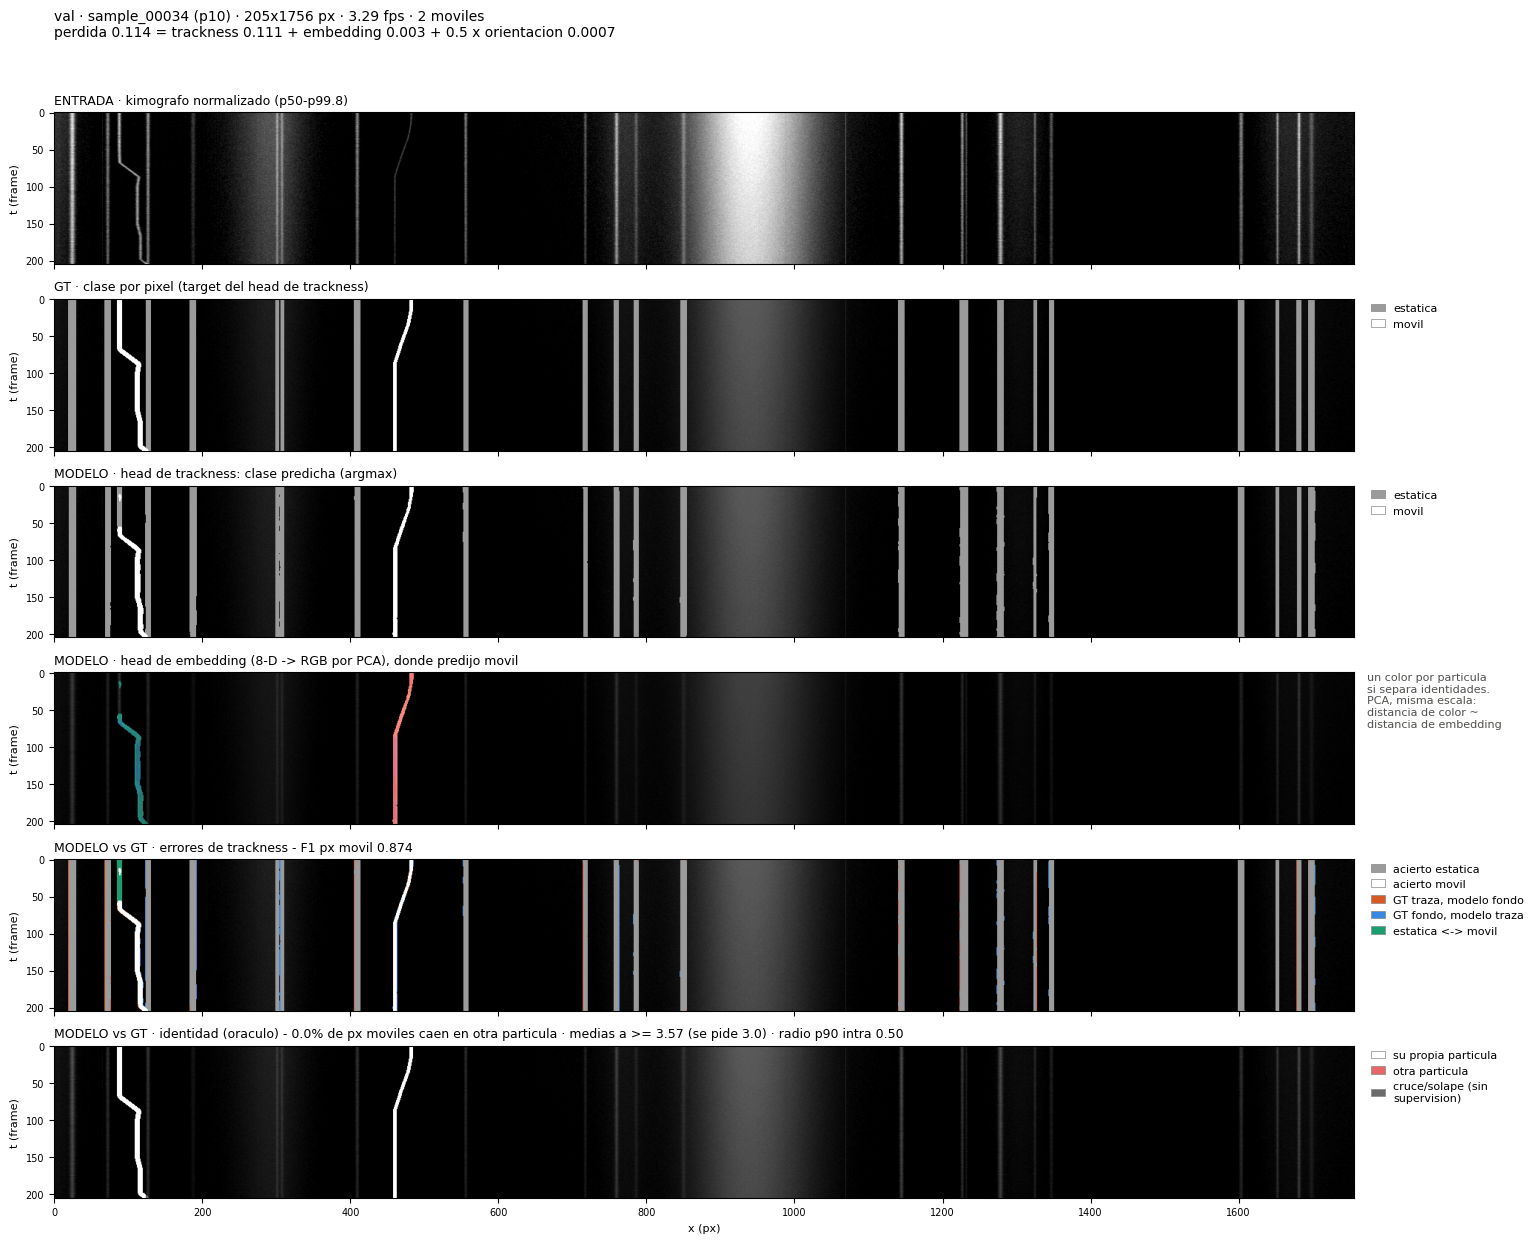

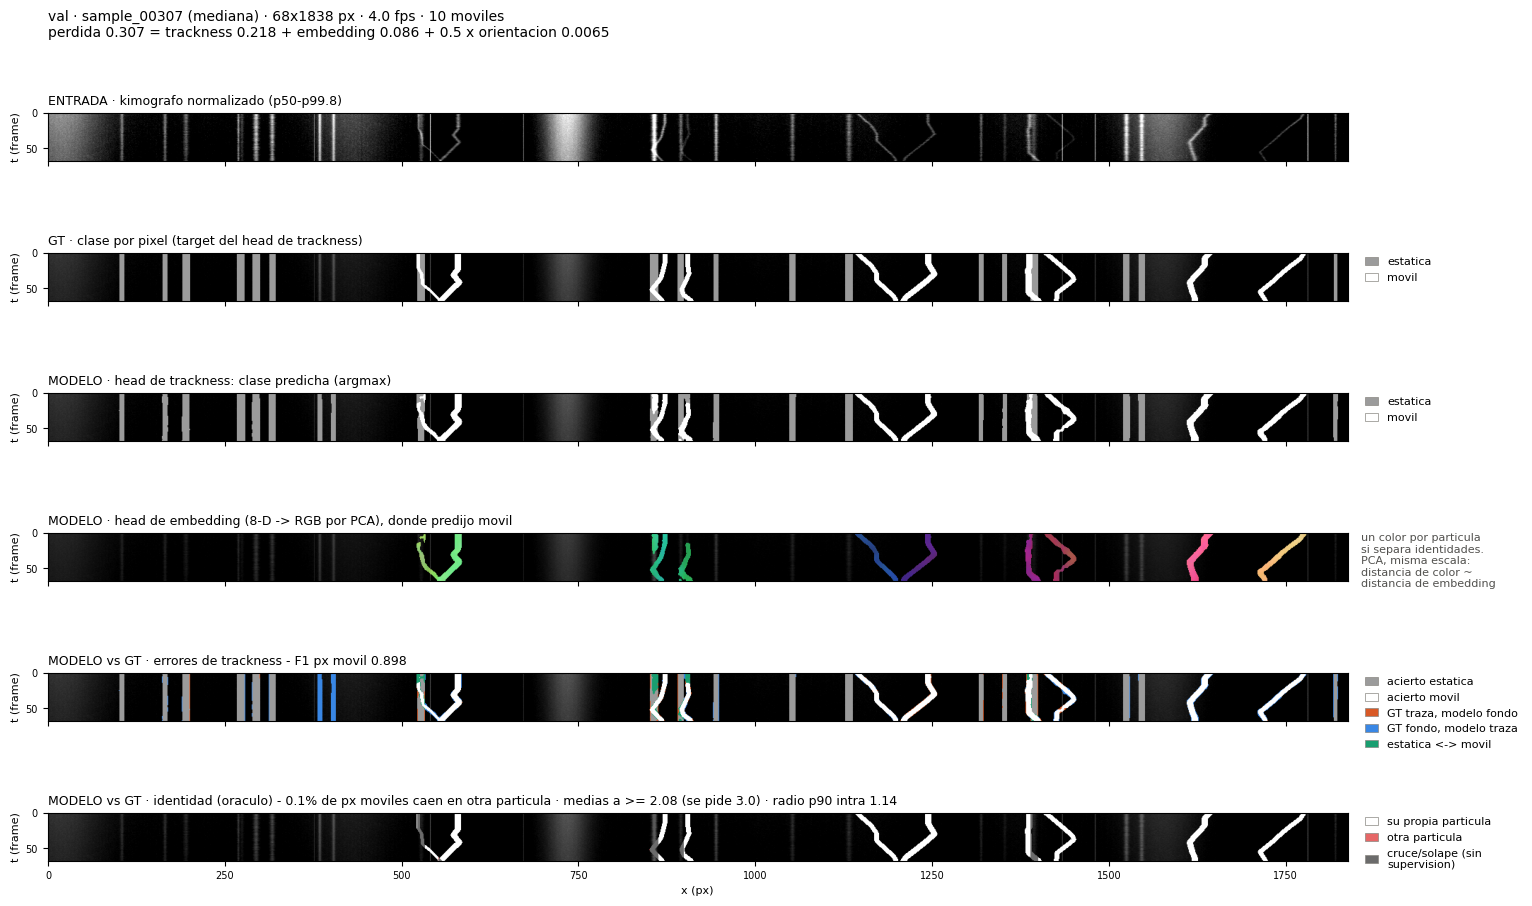

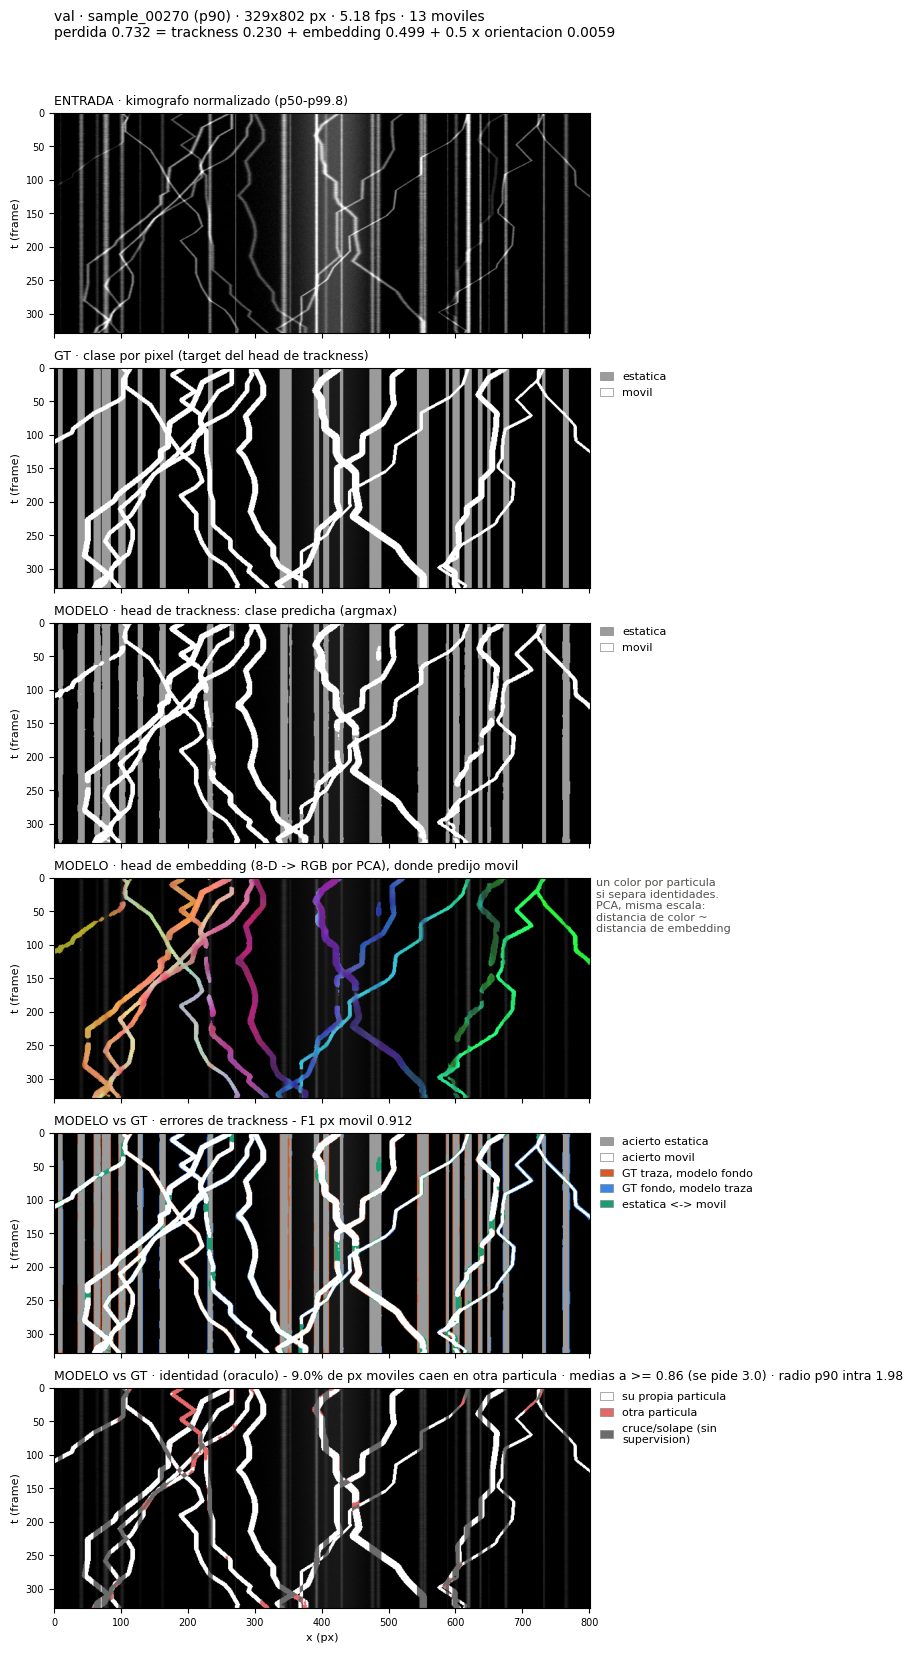

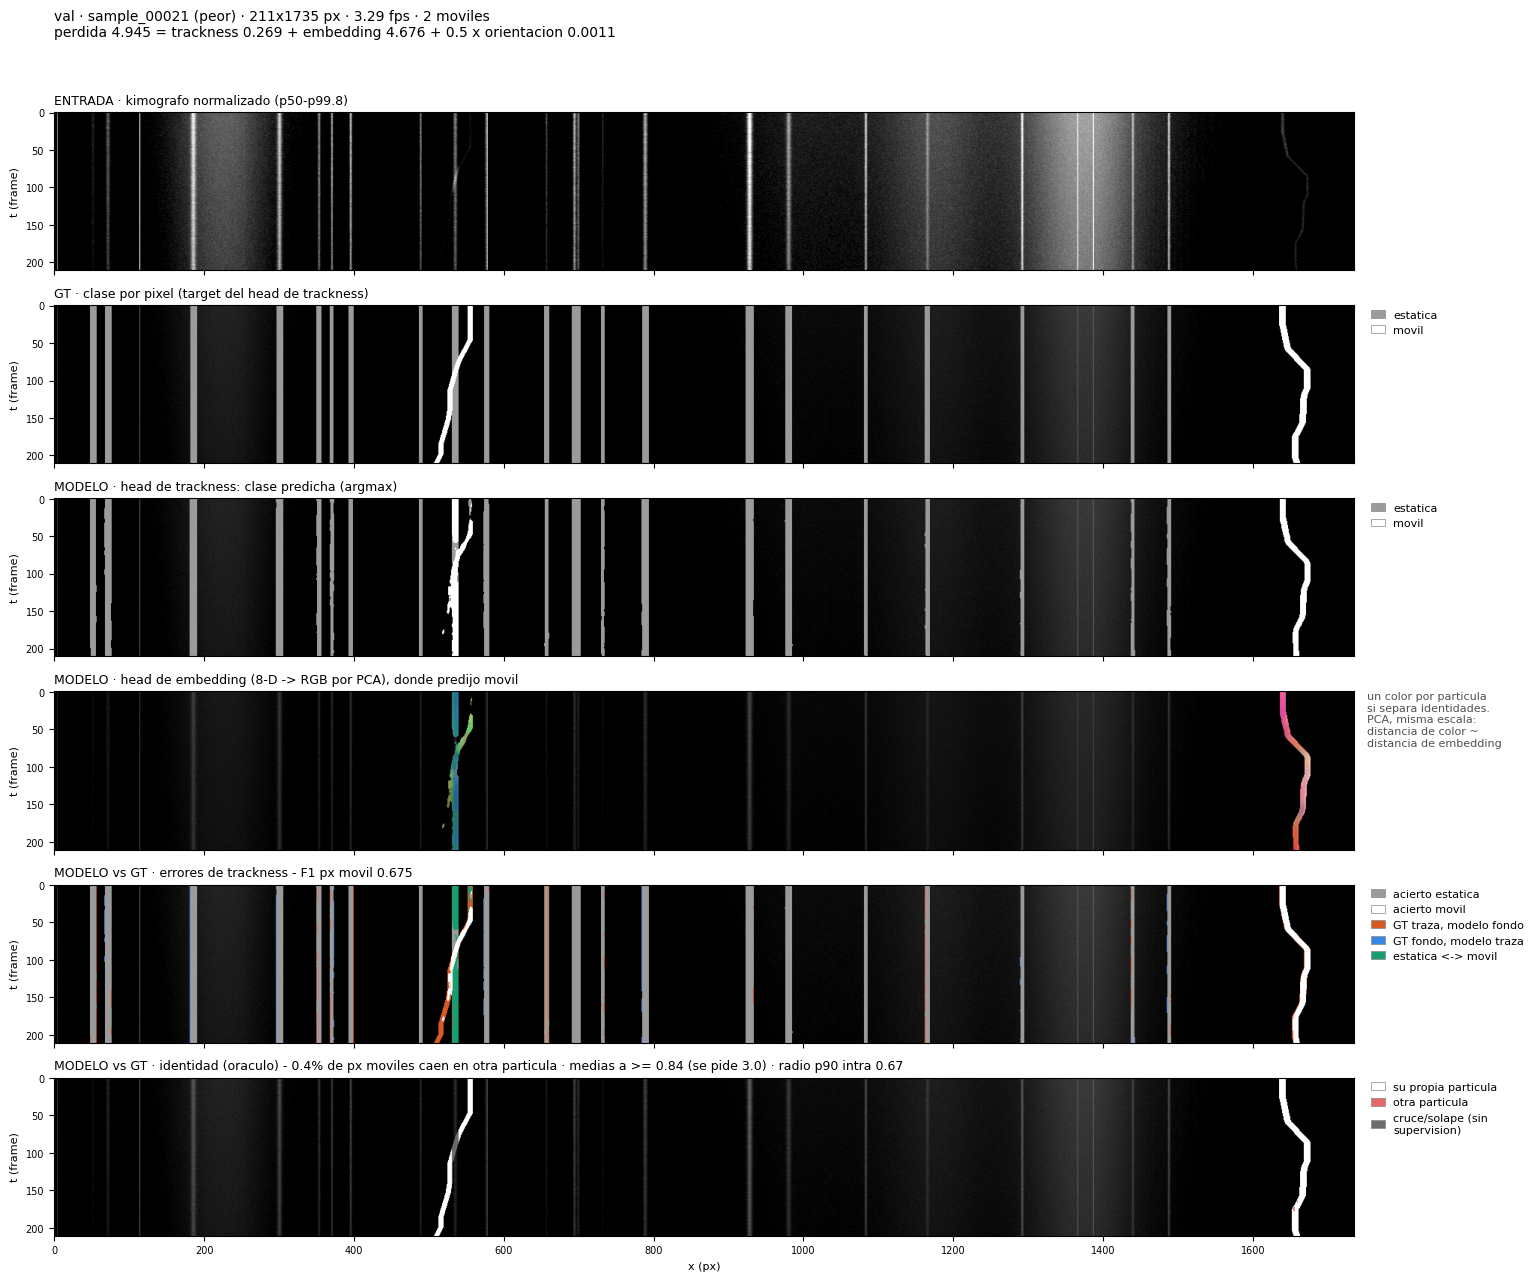

In [19]:
if RUTA_PESOS.exists():
    for etiqueta, i in elegidas.items():
        fig = ver_prediccion(i, etiqueta)
        plt.show()
        plt.close(fig)